Exploration of the dataset

In [ ]:
from pathlib import Path
import sys

#load the data

sys.path.append(str(Path("..").resolve()))
from src.load_data import load_data
df = load_data("data/raw")

In [2]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


First inspection

In [11]:
print(f"Dataframe shape: {df.shape}")
print("--------------------------------")
print(f"Dataframe columns:{df.columns.tolist()}")
print("--------------------------------")
print(f"Dataframe info: {df.info()}")
print("--------------------------------")
#how many missing values per column:
print(f"Missing values per column: {df.isna().sum()}")
print("--------------------------------")
print(f"Number of duplicated rows: {df.duplicated().sum()}")

Dataframe shape: (420768, 18)
--------------------------------
Dataframe columns:['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']
--------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 no

Understand the target

In [13]:
print(f"Description of PM 2.5: {df['PM2.5'].describe()}")

Description of PM 2.5: count    412029.000000
mean         79.793428
std          80.822391
min           2.000000
25%          20.000000
50%          55.000000
75%         111.000000
max         999.000000
Name: PM2.5, dtype: float64


Matplotlib is building the font cache; this may take a moment.


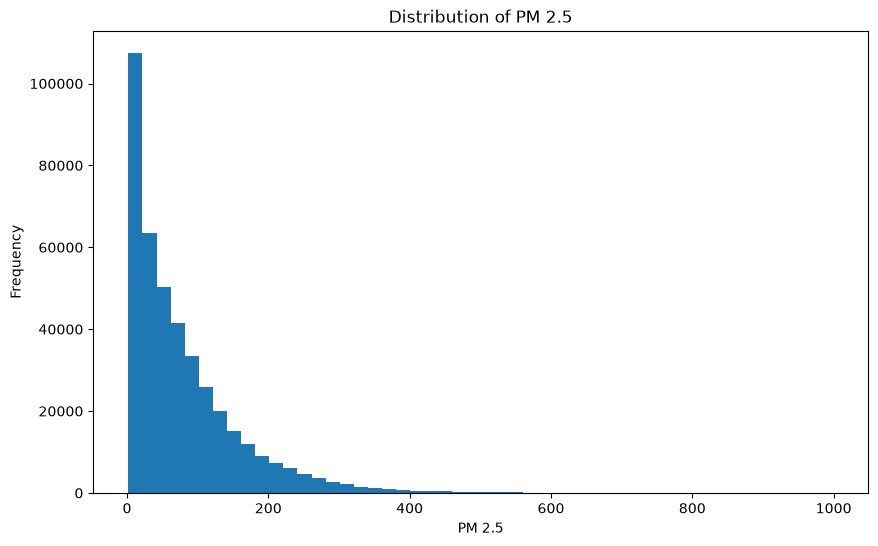

In [14]:
#VISUALIZATION
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.hist(df["PM2.5"].dropna(), bins= 50)
plt.xlabel("PM 2.5")
plt.ylabel("Frequency")
plt.title("Distribution of PM 2.5")
plt.show()

we can see a very assymetric distribution of the data.
We can probably characterize concentration above 400 as outliers.

In [15]:
df["station"].value_counts()

station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64

In [17]:
import pandas as pd
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])
df = df.sort_values("datetime")
print(f"dataframe total timeline:{df['datetime'].min()}, {df['datetime'].max()}")

dataframe total timeline:2013-03-01 00:00:00, 2017-02-28 23:00:00


Initial observations:

The data set contains 12 monitoring stations with each containing 35064 rows. We have 11 features (excluding the date) and 1 target variable (the PM 2.5). 
The timeline inclue data between 03/01/2013 and 28/02/2017.
In total here is 420768 rows.
For the target we have 412029 non-null which means that we are missing 8739 measurements. (We will probably remove the missing rows instead of filling them with the mean)

The histogram of the PM 2.5 is assymetric. We have a strong right-skewed distribution with a mean of 79.8 and a median of 55. (We will investigate the outliers before genuinely removing them because it could be severe pollution events). Also the standard deviation (=80.8) is roughly as large as the mean, therefore the target variable is highly volatile.

We are also missing measurements for the other features (with a max of 4.9% for the CO). The missingness is relatively limited.

Investigation of the extreme values

In [21]:
print(f"The 10 largest PM 2.5 values: {df["PM2.5"].nlargest(10)}")

The 10 largest PM 2.5 values: 411482    999.0
376418    957.0
306290    941.0
25778     898.0
60842     882.0
95905     881.0
411483    857.0
247020    844.0
279746    835.0
411481    826.0
Name: PM2.5, dtype: float64


In [25]:
df.nlargest(10, "PM2.5")[
    ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "wd", "WSPM", "station"]
]

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
411482,999.0,NaN,299.0,82.0,2700.0,6.0,-1.600,1009.9,-15.1,0.0,SW,1.1,Wanshouxigong
376418,957.0,NaN,282.0,92.0,1600.0,7.0,-3.600,1008.2,-14.7,0.0,SW,0.6,Wanliu
306290,941.0,NaN,153.0,70.0,2400.0,6.0,-3.900,1010.7,-13.6,0.0,NNE,1.1,Shunyi
25778,898.0,NaN,341.0,92.0,1900.0,10.0,-1.600,1009.9,-15.1,0.0,SW,1.1,Aotizhongxin
60842,882.0,NaN,215.0,81.0,2900.0,4.0,-2.400,1004.5,-15.5,0.0,ESE,0.7,Changping
95905,881.0,NaN,156.0,49.0,1100.0,20.0,-1.500,1005.4,-16.1,0.0,NNE,1.3,Dingling
411483,857.0,NaN,256.0,82.0,2400.0,6.0,-2.600,1008.8,-14.4,0.0,W,0.6,Wanshouxigong
247020,844.0,253.0,76.0,67.0,1399.0,141.0,25.800,1012.5,10.8,0.0,SW,2.6,Nongzhanguan
279746,835.0,939.0,212.0,74.0,2500.0,10.0,-2.975,1020.0,-14.9,0.0,NE,1.4,Nongzhanguan
411481,826.0,NaN,411.0,81.0,2400.0,7.0,-1.700,1010.5,-15.2,0.0,WSW,1.5,Wanshouxigong


So most of the time when we have big ouliers it seems that PM10 is missing, with negative temperatures, and low wind and no rain 

In [29]:
#investigate on the 999 values in the dataset
print(f"Number of 999 values in PM2.5: {df['PM2.5'].eq(999).sum()}")
print(f"Number of 500+ values in PM2.5: {(df['PM2.5']>=500).sum()}")
print(f"Frequency of 500+ values in PM2.5: {(df['PM2.5']>=500).mean() * 100:.2f}%")



Number of 999 values in PM2.5: 1
Number of 500+ values in PM2.5: 953
Frequency of 500+ values in PM2.5: 0.23%


exploration of the temporal structure (hours, days and months)

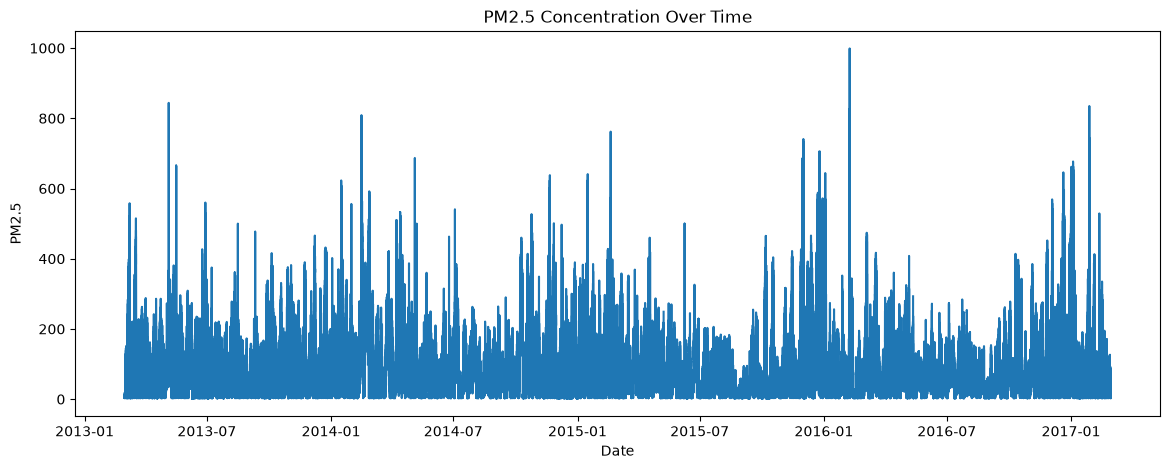

In [31]:
plt.figure(figsize=(14,5))
plt.plot(df["datetime"],df["PM2.5"])
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.title("PM2.5 Concentration Over Time")

plt.show()

We can see that usually, the PM2.5 concentration has a relatively low baseline. There is very short pollutions spikes and occasional very large pollution events (example: winter 2015-2016)

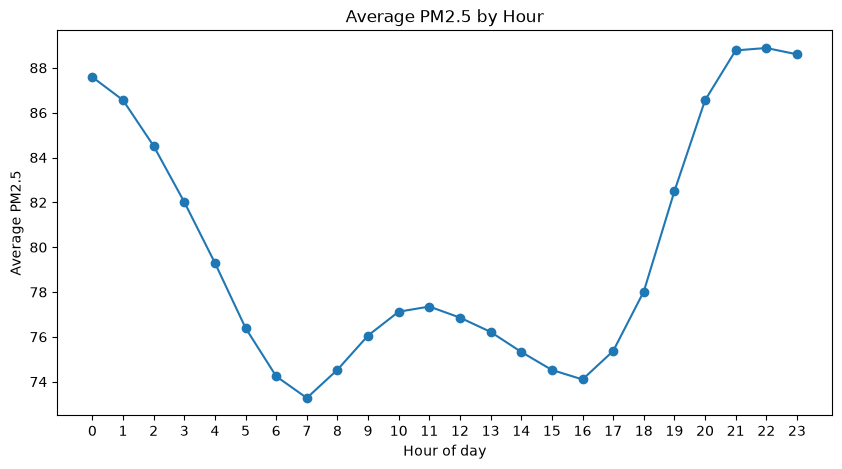

In [32]:
hourly_pm25 = df.groupby("hour")["PM2.5"].mean()
plt.figure(figsize=(10, 5))

plt.plot(hourly_pm25.index, hourly_pm25.values, marker="o")

plt.xlabel("Hour of day")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 by Hour")

plt.xticks(range(0, 24))

plt.show()

It seems that pollution is high during the night and stays relatively low during the day

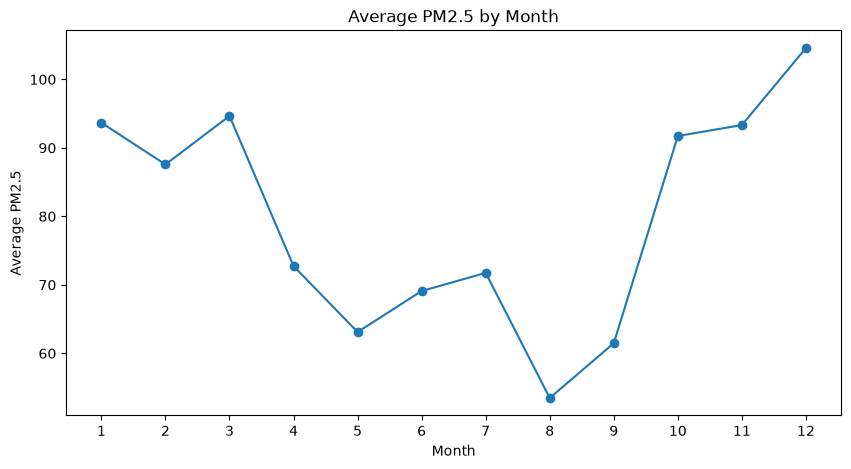

In [33]:
monthly_pm25 = df.groupby("month")["PM2.5"].mean()
plt.figure(figsize=(10, 5))

plt.plot(monthly_pm25.index, monthly_pm25.values, marker="o")

plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 by Month")

plt.xticks(range(1, 13))

plt.show()

We can see a strong seasonality in the data with high pollution during cold months and low pollution during hot ones.